In [23]:
import cv2
import numpy as np
import pytesseract
import easyocr
import re
import matplotlib.pyplot as plt
from imutils import perspective
from imutils.contours import sort_contours
from collections import Counter

In [24]:
reader = easyocr.Reader(['en', 'fr', 'de', 'es'])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


In [25]:
def show_image(title, img):
    plt.figure(figsize=(8, 6))
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


In [26]:
def deskew_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 100, minLineLength=50, maxLineGap=5)
    
    if lines is None:
        return image
    
    angles = [np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi for [[x1, y1, x2, y2]] in lines]
    skew_angle = np.median(angles) if angles else 0
    
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, skew_angle, 1.0)
    deskewed = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    show_image("Deskewed Image", deskewed)
    return deskewed


In [27]:
def preprocess_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(gray)
    blur = cv2.GaussianBlur(clahe, (5,5), 0)
    adaptive = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 7, 6)
    show_image("Preprocessed Image", adaptive)
    return adaptive

In [28]:
def detect_passport_region(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    morphed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    
    cnts, _ = cv2.findContours(morphed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not cnts:
        return image
    
    cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:3]
    for c in cnts:
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)
        if len(approx) == 4:
            passport_rect = perspective.four_point_transform(image, approx.reshape(4, 2))
            show_image("Detected Passport Region", passport_rect)
            return passport_rect
    return image

In [29]:
def extract_text(image):
    easyocr_text = reader.readtext(image, detail=0)
    custom_config = r'--oem 3 --psm 6'
    pytesseract_text = pytesseract.image_to_string(image, config=custom_config).split("\n")
    text_combined = easyocr_text + pytesseract_text
    return text_combined

In [30]:
def extract_key_details(text_list):
    """ Extracts key passport details using OCR and regex. """
    details = {
        "First Name": "Not Found",
        "Surname": "Not Found",
        "Date of Birth": "Not Found",
        "Date of Issue": "Not Found",
        "Expiry Date": "Not Found",
        "Nationality": "Not Found",
        "Passport Number": "Not Found",
        "MRZ Lines": []
    }

    for line in text_list:
        line = line.strip()

        # MRZ line detection
        if '<<' in line:
            details["MRZ Lines"].append(line)

        # Detect names (capital letters, no numbers)
        elif re.match(r'^[A-Z]+$', line):
            if details["Surname"] == "Not Found":
                details["Surname"] = line
            elif details["First Name"] == "Not Found":
                details["First Name"] = line

        # Detect dates (format: DD/MM/YYYY)
        elif re.search(r'\d{2}/\d{2}/\d{4}', line):
            if details["Date of Birth"] == "Not Found":
                details["Date of Birth"] = line
            elif details["Expiry Date"] == "Not Found":
                details["Expiry Date"] = line

        # Detect passport number (one letter + digits, possibly '<' characters)
        elif re.search(r'[A-Z]\d{6,9}', line):
            details["Passport Number"] = line.replace('<', '')

    return details

In [31]:
import re

def correct_using_mrz(details):
    """ Extracts correct details from MRZ lines if OCR is incorrect. """
    if len(details["MRZ Lines"]) == 2:
        mrz1, mrz2 = details["MRZ Lines"]  # First and Second MRZ lines
        
        # ✅ Ensure MRZ lines are correctly extracted
        mrz1 = mrz1.strip().replace(" ", "")
        mrz2 = mrz2.strip().replace(" ", "")

        # ✅ Extract Passport Number (First 9 characters from MRZ second line)
        details["Passport Number"] = mrz2[:9].replace("<", "")

        # ✅ Extract Nationality (Position 2-5 in MRZ first line)
        details["Nationality"] = mrz1[2:5].replace("<", "")

        # ✅ Extract Surname & First Name (MRZ1 after "<<")
        name_parts = mrz1.split("<<")
        if len(name_parts) > 1:
            details["Surname"] = name_parts[1].split("<")[0].upper()  # Convert to uppercase
        if len(name_parts) > 2:
            details["First Name"] = name_parts[2].replace("<", " ").strip()  # Replace '<' with space

        # ✅ Extract Date of Birth (YYMMDD format at position 13-19 in MRZ second line)
        dob_match = re.match(r"(\d{6})", mrz2[13:19])
        if dob_match:
            dob = dob_match.group(1)
            details["Date of Birth"] = f"19{dob[:2]}/{dob[2:4]}/{dob[4:]}" if int(dob[:2]) > 30 else f"20{dob[:2]}/{dob[2:4]}/{dob[4:]}"

        # ✅ Extract Expiry Date (YYMMDD format at position 21-27 in MRZ second line)
        expiry_match = re.match(r"(\d{6})", mrz2[21:27])
        if expiry_match:
            expiry = expiry_match.group(1)
            details["Expiry Date"] = f"20{expiry[:2]}/{expiry[2:4]}/{expiry[4:]}"

        # ✅ Extract Date of Issue (Calculating from Expiry Date - 10 years)
        if "Expiry Date" in details and re.match(r"\d{4}/\d{2}/\d{2}", details["Expiry Date"]):
            exp_year = int(details["Expiry Date"][:4])
            issue_year = exp_year - 10
            details["Date of Issue"] = f"{issue_year}/{details['Expiry Date'][5:]}"

    return details

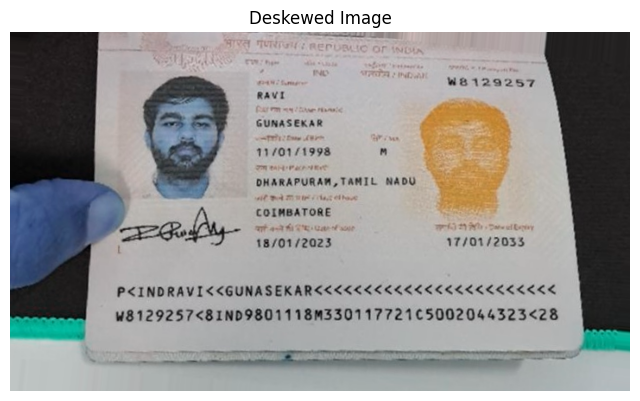

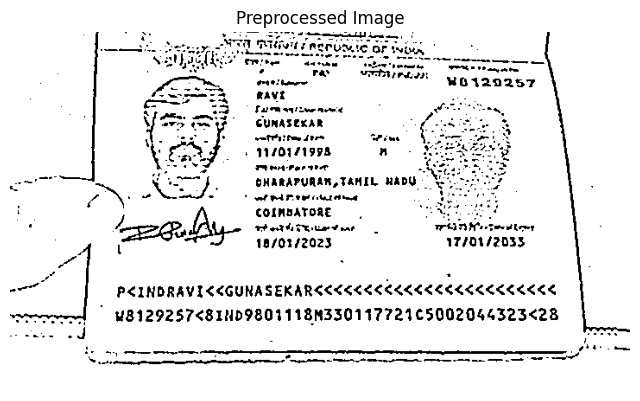


Extracted Details:
First Name: k(rkkkkkkkkkkk
Surname: GUNASEKAR
Date of Birth: 18/01/2023
Date of Issue: Not Found
Expiry Date: 17/01/2033
Nationality: IND
Passport Number: PINDRAVI
MRZ Lines: ['P<INDRAVI<<GUnaSEKaR<<<k(rkkkkkkkkkkk<<k<<', 'P<INDRAVI<<GUNASEKAR<<<K<< KKK KKK KKK KKK KKK KS']


In [32]:
def main(image_path):
    image = cv2.imread(image_path)
    deskewed = deskew_image(image)
    processed = preprocess_image(deskewed)
    passport_region = detect_passport_region(deskewed)
    text_data = extract_text(passport_region)
    details = extract_key_details(text_data)
    details = correct_using_mrz(details)
    
    print("\nExtracted Details:")
    for key, value in details.items():
        print(f"{key}: {value}")

if __name__ == "__main__":
    main("passport/1.jpg")